In [1]:
import pandas as pd

In [2]:
path_network_count = "/home/karen/Documents/GitHub/Muscle_wasting/network_count.csv"


In [3]:
df = pd.read_csv(path_network_count)

In [4]:
# remove the rows with NaN values
df = df.dropna()
df

,Network Final size,miRNA amount,Nodes,miRNAs,genes,Edges,density,DEGS,Proportion DEGs,Pathway 1,Pathway 2,Pathway 3,Tisuue,Cells,coeff_dds,coeff_tissue,coeff_cellular,coeff_pathway_svd,coeff_tf
1,Usecase0,complete_n_tf_mirnas__configuration01_cutoff_0...,241,39,202,914,0.03160,156,0.6473,GOCC_MITOCHONDRION,GOCC_ENVELOPE,GOBP_ORGANOPHOSPHATE_METABOLIC_PROCESS,HPA,HMA,1.0,1.0,1.0,1.0,1.0
2,Usecase0,complete_n_tf_mirnas__configuration02_cutoff_0...,240,38,202,907,0.03162,162,0.6750,GOCC_MITOCHONDRION,GOCC_ENVELOPE,GOBP_ORGANOPHOSPHATE_METABOLIC_PROCESS,HPA,HMA,1.0,0.0,0.0,0.0,0.0
3,Usecase0,complete_n_tf_mirnas__configuration03_cutoff_0...,242,40,202,932,0.03196,162,0.6694,GOCC_MITOCHONDRION,GOCC_ENVELOPE,GOBP_ORGANOPHOSPHATE_METABOLIC_PROCESS,HPA,HMA,0.0,1.0,0.0,0.0,0.0
4,Usecase0,complete_n_tf_mirnas__configuration04_cutoff_0...,239,37,202,907,0.03189,158,0.6611,GOCC_MITOCHONDRION,GOCC_ENVELOPE,GOBP_ORGANOPHOSPHATE_METABOLIC_PROCESS,HPA,HMA,0.0,0.0,1.0,0.0,0.0
5,Usecase0,complete_n_tf_mirnas__configuration05_cutoff_0...,239,37,202,907,0.03189,158,0.6611,GOCC_MITOCHONDRION,GOCC_ENVELOPE,GOBP_ORGANOPHOSPHATE_METABOLIC_PROCESS,HPA,HMA,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,Usecase9,complete_n_tf_mirnas__configuration20_cutoff_0...,134,24,110,391,0.04388,29,0.2164,GOBP_ATP_METABOLIC_PROCESS,KEGG_HUNTINGTONS_DISEASE,REACTOME_GLUCONEOGENESIS,Muscle,Sarcopenia,1.0,0.0,0.0,0.0,0.0
121,Usecase9,complete_n_tf_mirnas__configuration21_cutoff_0...,134,24,110,401,0.04500,29,0.2164,GOBP_ATP_METABOLIC_PROCESS,KEGG_HUNTINGTONS_DISEASE,REACTOME_GLUCONEOGENESIS,Muscle,Sarcopenia,0.0,1.0,0.0,0.0,0.0
122,Usecase9,complete_n_tf_mirnas__configuration22_cutoff_0...,134,24,110,391,0.04388,29,0.2164,GOBP_ATP_METABOLIC_PROCESS,KEGG_HUNTINGTONS_DISEASE,REACTOME_GLUCONEOGENESIS,Muscle,Sarcopenia,0.0,0.0,1.0,0.0,0.0
123,Usecase9,complete_n_tf_mirnas__configuration23_cutoff_0...,134,24,110,391,0.04388,29,0.2164,GOBP_ATP_METABOLIC_PROCESS,KEGG_HUNTINGTONS_DISEASE,REACTOME_GLUCONEOGENESIS,Muscle,Sarcopenia,0.0,0.0,0.0,1.0,0.0


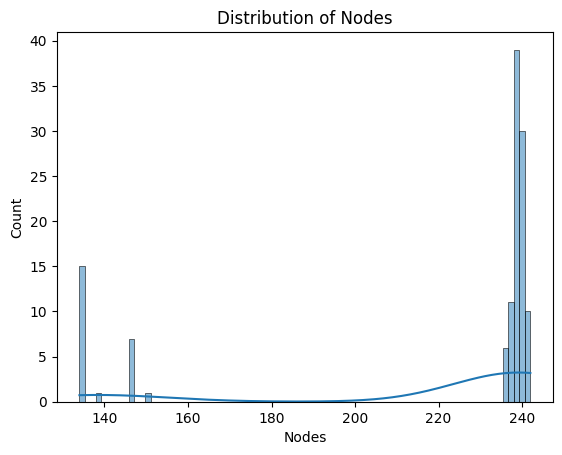

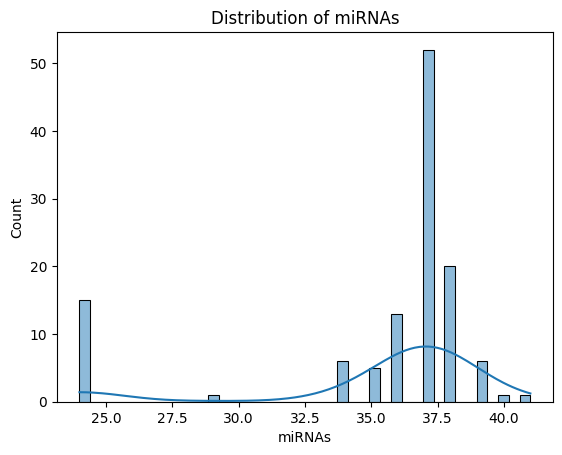

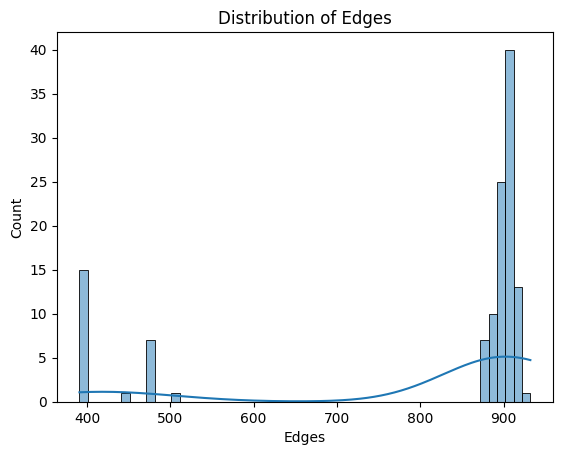

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

for var in ['Nodes', 'miRNAs', 'Edges']:
    sns.histplot(df[var], kde=True)
    plt.title(f'Distribution of {var}')
    plt.show()

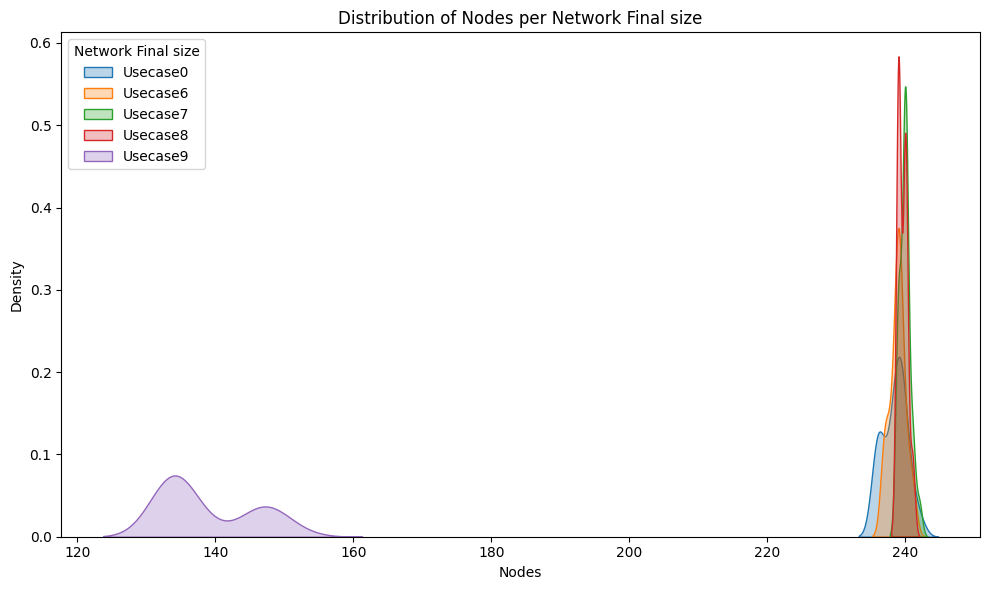

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is already loaded and cleaned (with numeric types)
# Group by the first column (e.g. 'Network Final size' or 'Usecase')
group_col = df.columns[0]  # First column in the dataframe
value_col = 'Nodes'        # Output variable to plot

plt.figure(figsize=(10, 6))

# Iterate through each group
for name, group in df.groupby(group_col):
    sns.kdeplot(group[value_col], label=name, fill=True, alpha=0.3)

plt.title(f'Distribution of {value_col} per {group_col}')
plt.xlabel(value_col)
plt.ylabel('Density')
plt.legend(title=group_col)
plt.tight_layout()
plt.savefig('distribution_per_group_nodes.svg')
plt.show()

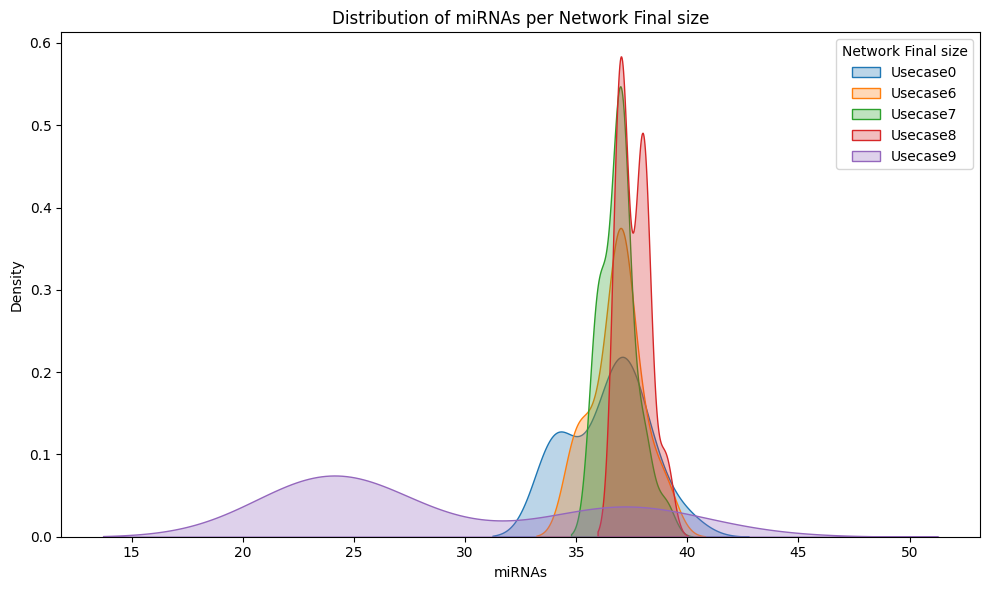

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is already loaded and cleaned (with numeric types)
# Group by the first column (e.g. 'Network Final size' or 'Usecase')
group_col = df.columns[0]  # First column in the dataframe
value_col = 'miRNAs'        # Output variable to plot

plt.figure(figsize=(10, 6))

# Iterate through each group
for name, group in df.groupby(group_col):
    sns.kdeplot(group[value_col], label=name, fill=True, alpha=0.3)

plt.title(f'Distribution of {value_col} per {group_col}')
plt.xlabel(value_col)
plt.ylabel('Density')
plt.legend(title=group_col)

plt.tight_layout()
plt.savefig('distribution_per_group_mirnas.svg')
plt.show()

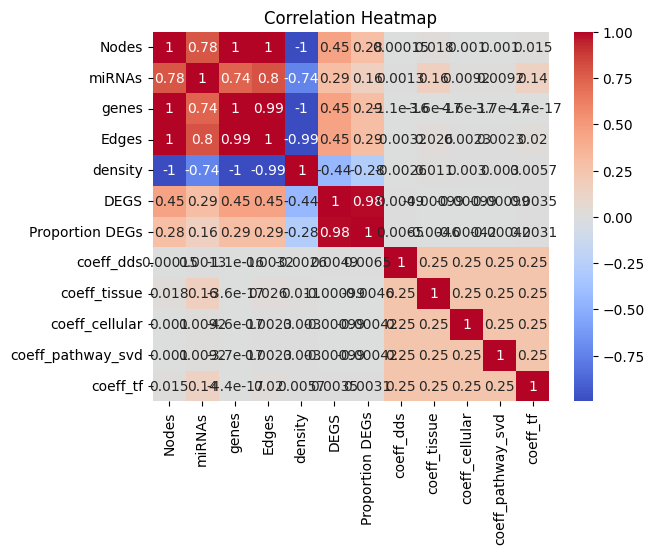

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_cols = df.select_dtypes(include='number')
corr = numeric_cols.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

/tmp/ipykernel_24048/513573445.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Group'] = df['miRNAs'].apply(lambda x: 'High' if x > df['miRNAs'].median() else 'Low')


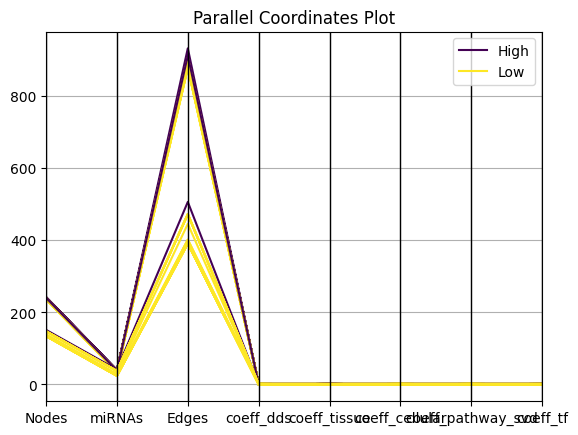

In [10]:
from pandas.plotting import parallel_coordinates

# Optionally: create a group label (e.g., based on DEGs or miRNAs)
df['Group'] = df['miRNAs'].apply(lambda x: 'High' if x > df['miRNAs'].median() else 'Low')

selected_cols = ['Nodes', 'miRNAs', 'Edges',
                 'coeff_dds', 'coeff_tissue', 'coeff_cellular',
                 'coeff_pathway_svd', 'coeff_tf', 'Group']

parallel_coordinates(df[selected_cols], class_column='Group', colormap=plt.cm.viridis)
plt.title("Parallel Coordinates Plot")
plt.show()

In [13]:
import statsmodels.api as sm

# Loop through each input and output pair
inputs = ['coeff_dds', 'coeff_tissue', 'coeff_cellular', 'coeff_pathway_svd', 'coeff_tf']
outputs = ['Nodes', 'miRNAs', 'Edges']

for y_var in outputs:
    print(f"\nRegression on {y_var}")
    for x_var in inputs:
        X = sm.add_constant(df[x_var])
        y = df[y_var]
        model = sm.OLS(y, X).fit()
        print(f"{x_var} → {y_var}: coef={model.params[1]:.2f}, p={model.pvalues[1]:.4f}")


Regression on Nodes
coeff_dds → Nodes: coef=0.01, p=0.9987
coeff_tissue → Nodes: coef=1.51, p=0.8479
coeff_cellular → Nodes: coef=0.09, p=0.9911
coeff_pathway_svd → Nodes: coef=0.09, p=0.9911
coeff_tf → Nodes: coef=1.33, p=0.8666

Regression on miRNAs
coeff_dds → miRNAs: coef=0.01, p=0.9886
coeff_tissue → miRNAs: coef=1.51, p=0.0823
coeff_cellular → miRNAs: coef=0.09, p=0.9204
coeff_pathway_svd → miRNAs: coef=0.09, p=0.9204
coeff_tf → miRNAs: coef=1.33, p=0.1285

Regression on Edges
coeff_dds → Edges: coef=-1.30, p=0.9725
coeff_tissue → Edges: coef=10.51, p=0.7804
coeff_cellular → Edges: coef=0.95, p=0.9799
coeff_pathway_svd → Edges: coef=0.95, p=0.9799
coeff_tf → Edges: coef=8.11, p=0.8296


/tmp/ipykernel_24048/2302542992.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{x_var} → {y_var}: coef={model.params[1]:.2f}, p={model.pvalues[1]:.4f}")
/tmp/ipykernel_24048/2302542992.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{x_var} → {y_var}: coef={model.params[1]:.2f}, p={model.pvalues[1]:.4f}")
/tmp/ipykernel_24048/2302542992.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{x_var} →

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt



RandomForestRegressor(random_state=42)

In [32]:
def plot_shaps(variable='Nodes'):
    X = df[['coeff_dds', 'coeff_tissue', 'coeff_cellular', 'coeff_pathway_svd', 'coeff_tf']]
    y = df[variable]  

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    explainer = shap.Explainer(model, X)
    shap_values = explainer(X)
    
    summapty_plot =  shap.summary_plot(shap_values, X, show=False)
    plt.savefig(f'/home/karen/Documents/GitHub/Muscle_wasting/Evaluation_notebooks/shap_summary_plot_{variable}.svg')
    plt.clf()  # Clear the current figure to avoid overlap
    shap.plots.bar(shap_values, show=False)
    plt.savefig(f'/home/karen/Documents/GitHub/Muscle_wasting/Evaluation_notebooks/shap_bar_plot_{variable}.svg')
    return shap_values


.values =
array([[-0.07266941,  0.72234638, -0.14144048, -0.1444397 ,  0.5347997 ],
       [-0.27289466, -0.54124047,  0.10609221,  0.07985175, -0.39391566],
       [ 0.08318101,  0.9296807 ,  0.11165061,  0.10626883, -0.18703201],
       [ 0.085746  , -0.53172838, -0.34561217,  0.07469906, -0.38726225],
       [ 0.09685741, -0.49663715,  0.11125631, -0.24266886, -0.37313362],
       [ 0.09147639, -0.31277946,  0.11734687,  0.09402555,  0.73908926],
       [-0.07266941,  0.72234638, -0.14144048, -0.1444397 ,  0.5347997 ],
       [-0.27289466, -0.54124047,  0.10609221,  0.07985175, -0.39391566],
       [ 0.08318101,  0.9296807 ,  0.11165061,  0.10626883, -0.18703201],
       [ 0.085746  , -0.53172838, -0.34561217,  0.07469906, -0.38726225],
       [ 0.09685741, -0.49663715,  0.11125631, -0.24266886, -0.37313362],
       [ 0.09147639, -0.31277946,  0.11734687,  0.09402555,  0.73908926],
       [-0.07266941,  0.72234638, -0.14144048, -0.1444397 ,  0.5347997 ],
       [-0.27289466, -0.5412

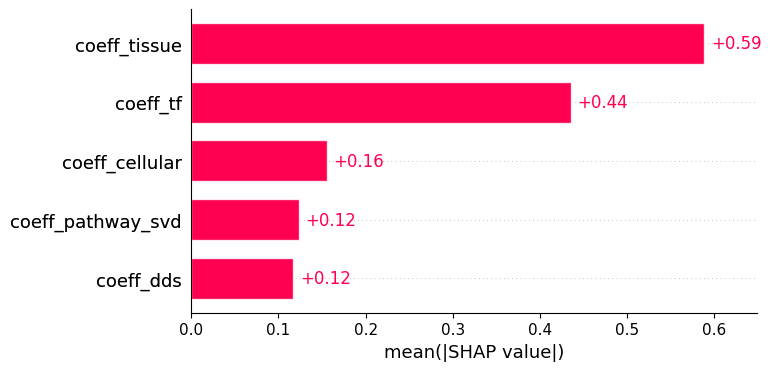

In [40]:
plot_shaps(variable='miRNAs')

In [28]:
shap_df

,coeff_dds,coeff_tissue,coeff_cellular,coeff_pathway_svd,coeff_tf
0,-0.072669,0.722346,-0.141440,-0.144440,0.534800
1,-0.272895,-0.541240,0.106092,0.079852,-0.393916
2,0.083181,0.929681,0.111651,0.106269,-0.187032
3,0.085746,-0.531728,-0.345612,0.074699,-0.387262
4,0.096857,-0.496637,0.111256,-0.242669,-0.373134
...,...,...,...,...,...
115,-0.272895,-0.541240,0.106092,0.079852,-0.393916
116,0.083181,0.929681,0.111651,0.106269,-0.187032
117,0.085746,-0.531728,-0.345612,0.074699,-0.387262
118,0.096857,-0.496637,0.111256,-0.242669,-0.373134


coeff_dds: 95% CI = [-0.029, 0.017]
coeff_tissue: 95% CI = [-0.235, 0.136]
coeff_cellular: 95% CI = [-0.129, 0.080]
coeff_pathway_svd: 95% CI = [-0.035, 0.030]
coeff_tf: 95% CI = [-0.064, 0.073]
Mean absolute SHAP values (importance):
coeff_tissue         0.945885
coeff_cellular       0.501227
coeff_tf             0.340769
coeff_pathway_svd    0.151851
coeff_dds            0.107096
dtype: float64
Mean SHAP values (directional impact):
coeff_tissue        -0.057553
coeff_cellular      -0.019918
coeff_dds           -0.006081
coeff_pathway_svd   -0.002543
coeff_tf             0.003631
dtype: float64
coeff_dds: 95% CI = [-0.023, 0.025]
coeff_tissue: 95% CI = [-0.145, 0.063]
coeff_cellular: 95% CI = [-0.038, 0.025]
coeff_pathway_svd: 95% CI = [-0.031, 0.019]
coeff_tf: 95% CI = [-0.093, 0.066]
Mean absolute SHAP values (importance):
coeff_tissue         0.589069
coeff_tf             0.435872
coeff_cellular       0.155566
coeff_pathway_svd    0.123659
coeff_dds            0.117137
dtype: floa

{'Nodes': {'coeff_dds': {'mean_abs_shap': 0.1070957664648693,
   'mean_shap': -0.006081261634826656,
   'bootstrap_ci': (-0.028976945664485294, 0.016615761493518948)},
  'coeff_tissue': {'mean_abs_shap': 0.9458845609426487,
   'mean_shap': -0.057552648782730045,
   'bootstrap_ci': (-0.2352204848156621, 0.1359901679062595)},
  'coeff_cellular': {'mean_abs_shap': 0.5012273802359898,
   'mean_shap': -0.019918068051338236,
   'bootstrap_ci': (-0.12938430804039042, 0.08044049644346037)},
  'coeff_pathway_svd': {'mean_abs_shap': 0.15185121635595963,
   'mean_shap': -0.0025429723660151176,
   'bootstrap_ci': (-0.03537506747978429, 0.02991925753628215)},
  'coeff_tf': {'mean_abs_shap': 0.34076852977275823,
   'mean_shap': 0.00363093833128612,
   'bootstrap_ci': (-0.06394740763468044, 0.07298877628768484)}},
 'miRNAs': {'coeff_dds': {'mean_abs_shap': 0.11713748104870314,
   'mean_shap': 0.0019494587928056695,
   'bootstrap_ci': (-0.02323045145035721, 0.024567109342912827)},
  'coeff_tissue': {'

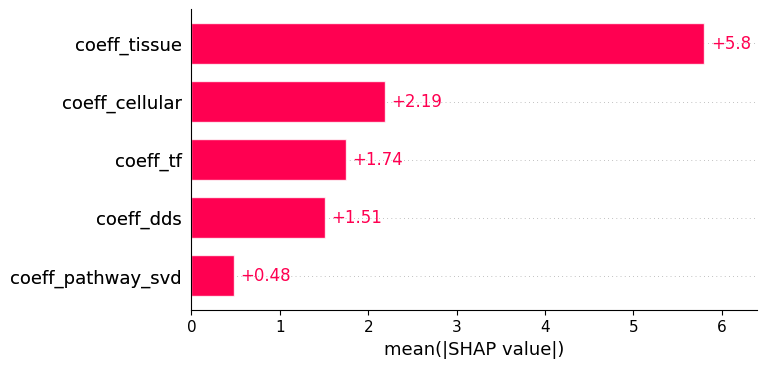

In [38]:

import numpy as np
import pandas as pd
all_results = {}

varibales = ['Nodes', 'miRNAs', 'Edges']
for variable in varibales:
    results = {
        'coeff_dds': {},
        'coeff_tissue': {},
        'coeff_cellular': {},
        'coeff_pathway_svd': {},
        'coeff_tf': {}
    }
    shap_values = plot_shaps(variable=variable)
    shap_df = pd.DataFrame(shap_values.values, columns=X.columns)

    mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)
    for col in shap_df.columns:
        results[col]['mean_abs_shap'] = mean_abs_shap[col]
    mean_shap = shap_df.mean().sort_values()

    for col in shap_df.columns:
        results[col]['mean_shap'] = mean_shap[col]

    bootstrap_means = {}

    for col in shap_df.columns:
        samples = [shap_df[col].sample(frac=1, replace=True).mean() for _ in range(1000)]
        bootstrap_means[col] = (np.percentile(samples, 2.5), np.percentile(samples, 97.5))

    for col, (low, high) in bootstrap_means.items():
        results[col]['bootstrap_ci'] = (low, high)
        print(f"{col}: 95% CI = [{low:.3f}, {high:.3f}]")


    print("Mean absolute SHAP values (importance):")
    print(mean_abs_shap)

    print("Mean SHAP values (directional impact):")
    print(mean_shap)
    all_results[variable] = results

all_results

In [39]:
all_results_df = pd.DataFrame(all_results).T
all_results_df.to_csv('/home/karen/Documents/GitHub/Muscle_wasting/Evaluation_notebooks/shap_results.csv')

Mean SHAP values (directional impact):
coeff_tissue        -0.038393
coeff_tf            -0.011242
coeff_cellular      -0.006784
coeff_pathway_svd   -0.005377
coeff_dds            0.001949
dtype: float64


Bootstrap Confidence Intervals
Estimate a 95% CI for the mean SHAP value of each feature.
✅ If the CI doesn’t include 0, the SHAP effect is likely statistically significant.



coeff_dds: 95% CI = [-0.023, 0.027]
coeff_tissue: 95% CI = [-0.151, 0.075]
coeff_cellular: 95% CI = [-0.039, 0.026]
coeff_pathway_svd: 95% CI = [-0.030, 0.016]
coeff_tf: 95% CI = [-0.089, 0.079]


Visual Significance: SHAP Dependence Plots
If you’re looking for evidence that ON/OFF matters:

python
Copy
Edit

If there's clear separation between SHAP values when the feature is 0 vs 1, it’s likely meaningful.

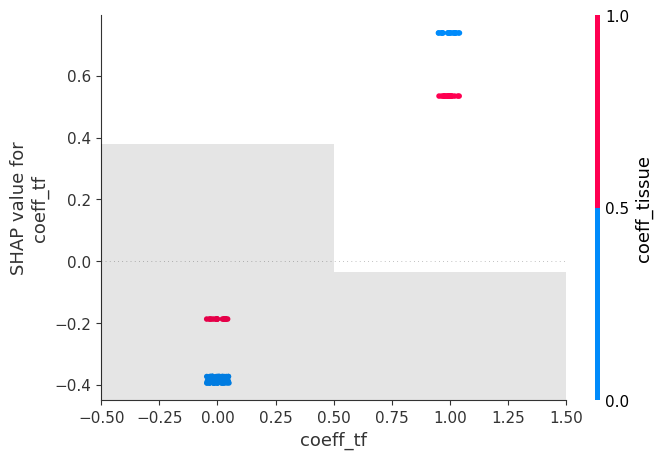

In [35]:
shap.plots.scatter(shap_values[:, "coeff_tf"], color=shap_values)
